In [4]:
import os
import hashlib
import numpy as np
from PIL import Image
from collections import defaultdict
import plotly.graph_objects as go
import matplotlib.pyplot as plt


In [5]:
train_dir = "Fruits/train/train"

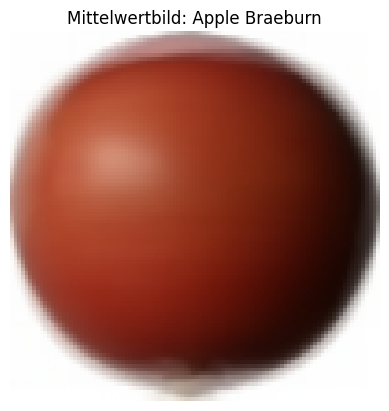

Randanteil im Mittelwertbild: 10.00%


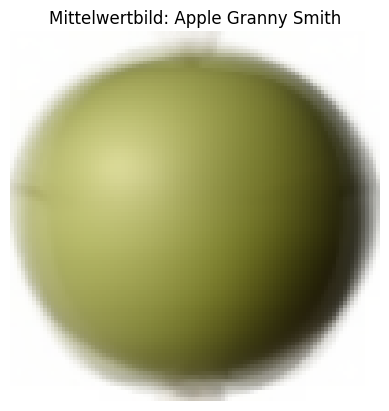

Randanteil im Mittelwertbild: 9.95%


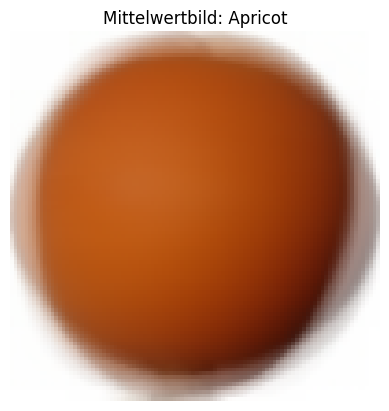

Randanteil im Mittelwertbild: 9.87%


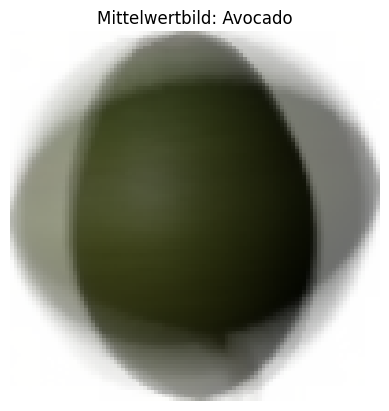

Randanteil im Mittelwertbild: 10.00%


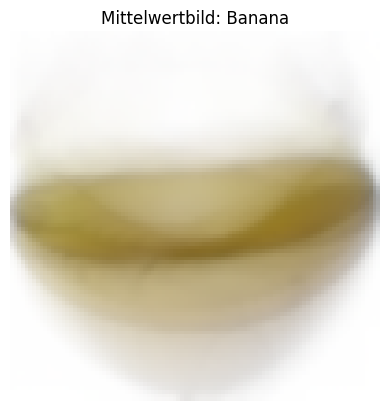

Randanteil im Mittelwertbild: 9.83%


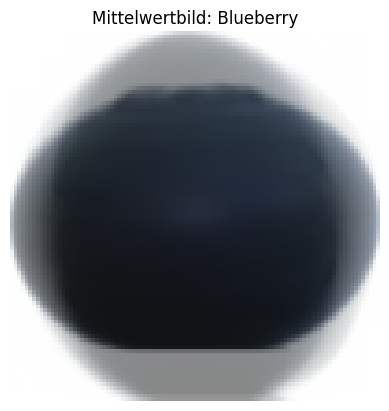

Randanteil im Mittelwertbild: 9.93%


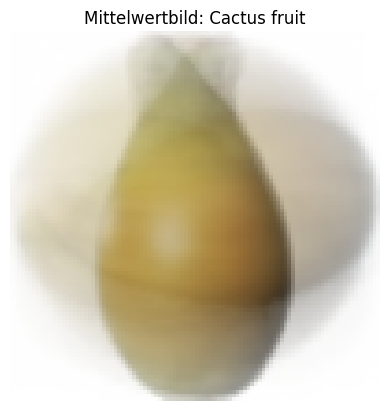

Randanteil im Mittelwertbild: 9.99%


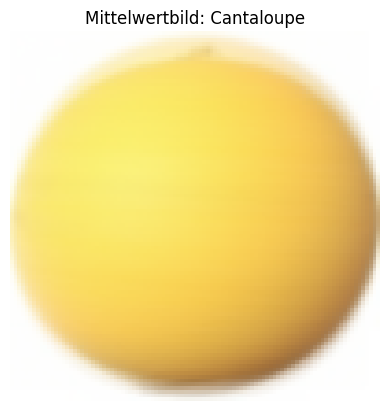

Randanteil im Mittelwertbild: 9.91%


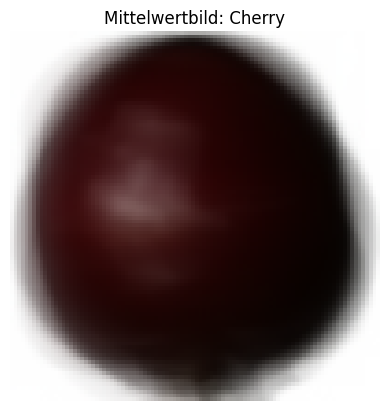

Randanteil im Mittelwertbild: 9.96%


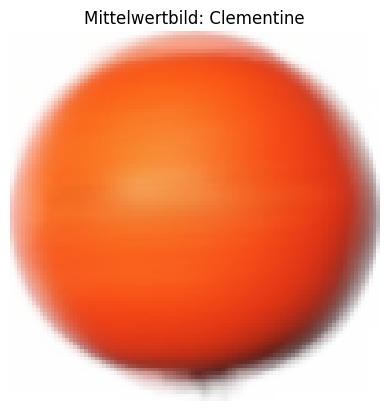

Randanteil im Mittelwertbild: 9.98%


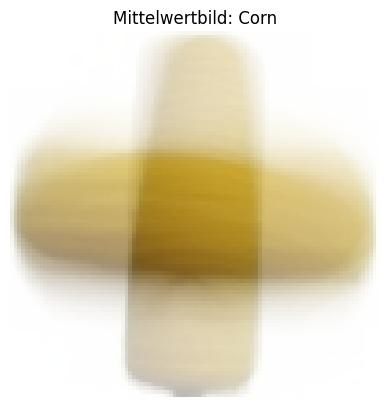

Randanteil im Mittelwertbild: 9.75%


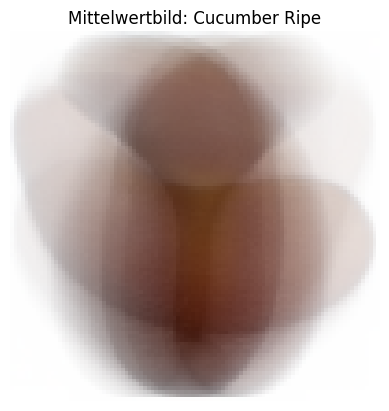

Randanteil im Mittelwertbild: 9.89%


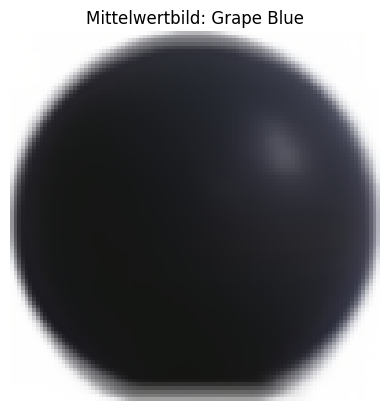

Randanteil im Mittelwertbild: 9.99%


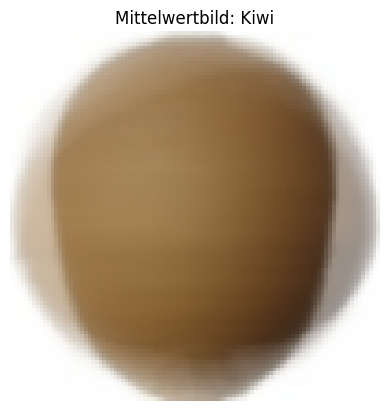

Randanteil im Mittelwertbild: 9.90%


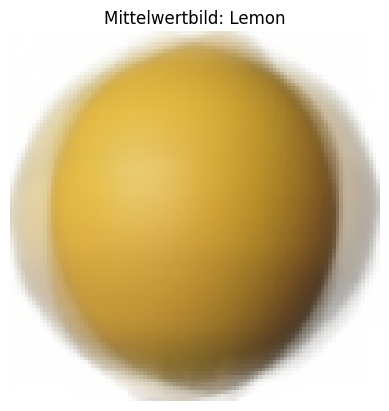

Randanteil im Mittelwertbild: 10.00%


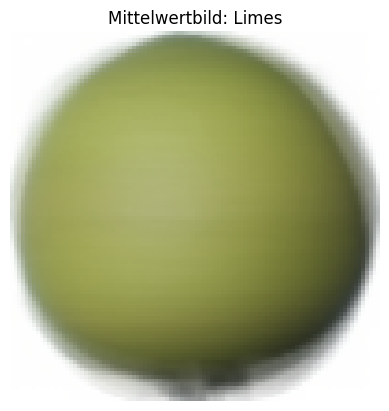

Randanteil im Mittelwertbild: 9.95%


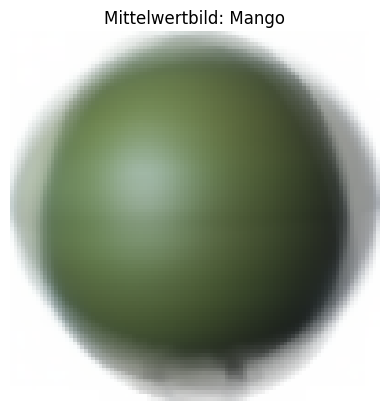

Randanteil im Mittelwertbild: 9.98%


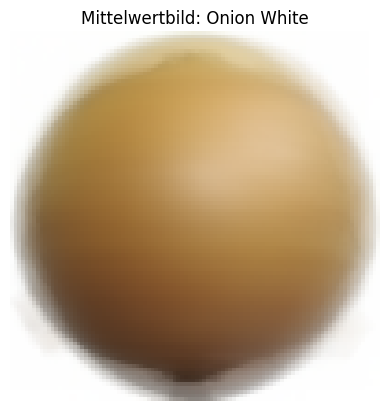

Randanteil im Mittelwertbild: 9.91%


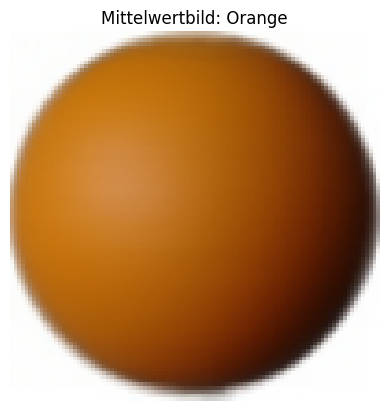

Randanteil im Mittelwertbild: 9.98%


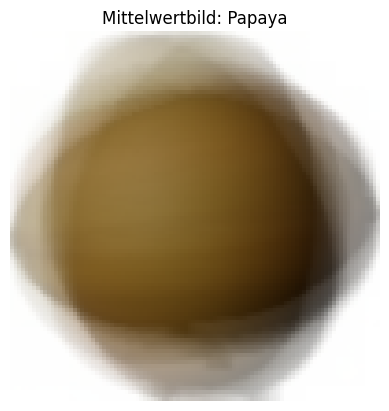

Randanteil im Mittelwertbild: 9.92%


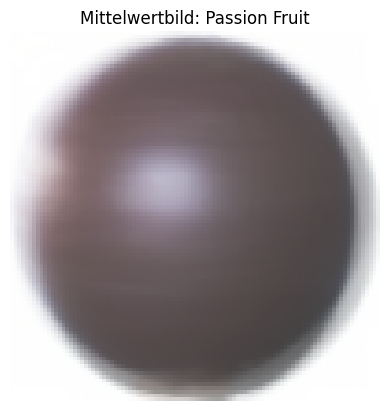

Randanteil im Mittelwertbild: 9.99%


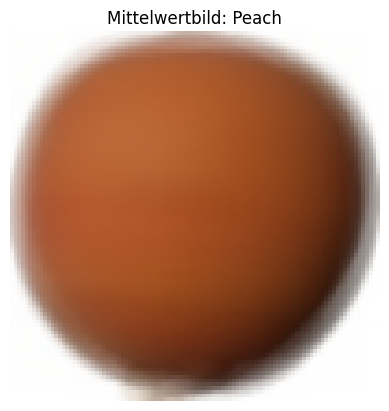

Randanteil im Mittelwertbild: 9.96%


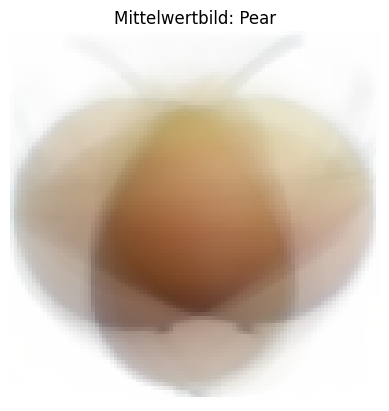

Randanteil im Mittelwertbild: 9.91%


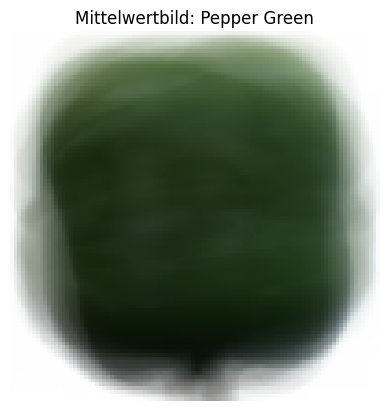

Randanteil im Mittelwertbild: 9.88%


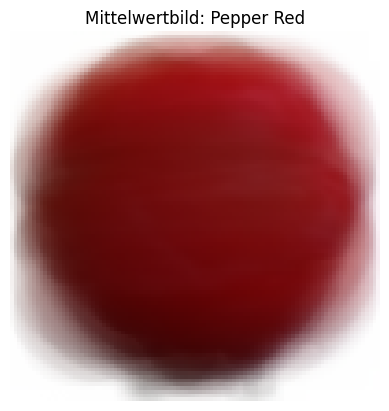

Randanteil im Mittelwertbild: 9.98%


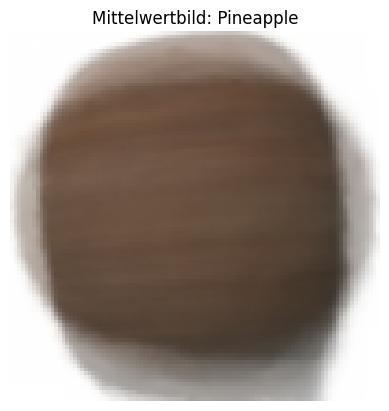

Randanteil im Mittelwertbild: 9.95%


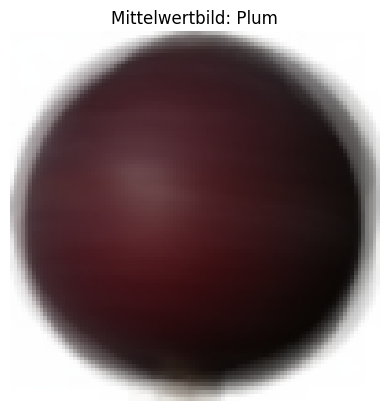

Randanteil im Mittelwertbild: 9.97%


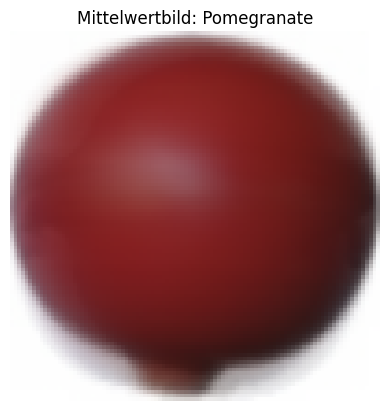

Randanteil im Mittelwertbild: 9.99%


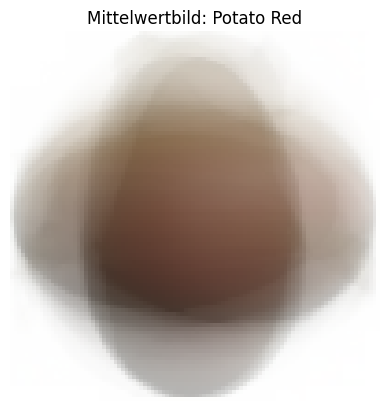

Randanteil im Mittelwertbild: 9.67%


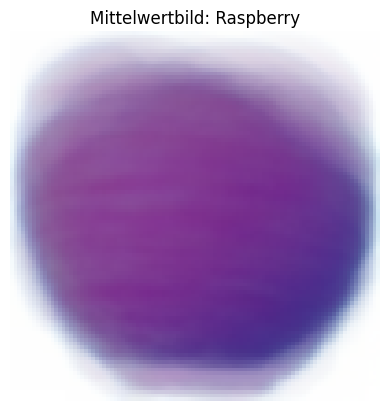

Randanteil im Mittelwertbild: 10.00%


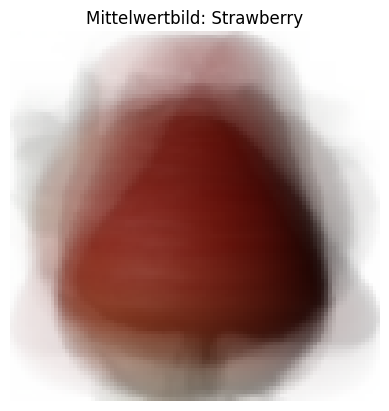

Randanteil im Mittelwertbild: 9.72%


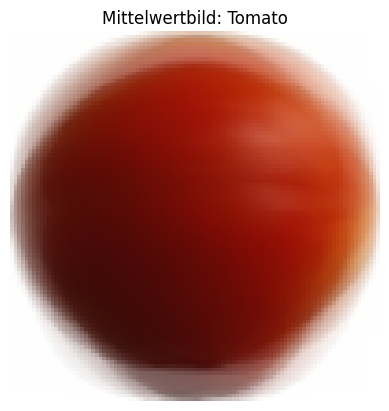

Randanteil im Mittelwertbild: 10.00%


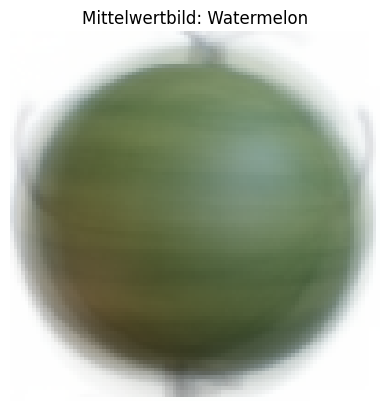

Randanteil im Mittelwertbild: 9.85%


In [6]:

root_dir = train_dir

for subfolder in os.listdir(root_dir):
    subfolder_path = os.path.join(root_dir, subfolder)

    if not os.path.isdir(subfolder_path):
        continue

    images = []

    for file in os.listdir(subfolder_path):
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            img_path = os.path.join(subfolder_path, file)
            img = Image.open(img_path).convert("RGB")
            images.append(np.array(img, dtype=np.float32))

    if not images:
        continue

    # Mittelwertbild berechnen
    mean_image = np.mean(images, axis=0).astype(np.uint8)
    

    # Anzeigen
    plt.figure()
    plt.imshow(mean_image)
    plt.title(f"Mittelwertbild: {subfolder}")
    plt.axis("off")
    plt.show()

    # 1️⃣ Graustufen
    mean_gray = np.mean(mean_image, axis=2)  # Helligkeit

    # 2️⃣ Gradient approximieren (sobel-artig)
    grad_x = np.abs(np.diff(mean_gray, axis=1, append=mean_gray[:, -1:]))
    grad_y = np.abs(np.diff(mean_gray, axis=0, append=mean_gray[-1:, :]))
    gradient = grad_x + grad_y

    # 3️⃣ Pixel als Rand definieren (z.B. Gradient > Threshold)
    threshold = np.percentile(gradient, 90)  # top 10% der Gradienten
    edge_mask = gradient > threshold

    # 4️⃣ Prozentualer Anteil der Randpixel
    percent_edge = 100 * edge_mask.sum() / edge_mask.size

    print(f"Randanteil im Mittelwertbild: {percent_edge:.2f}%")


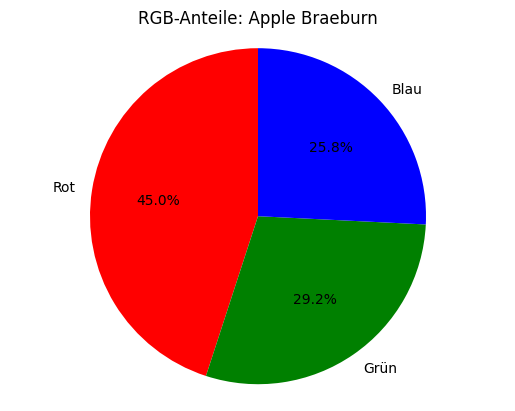

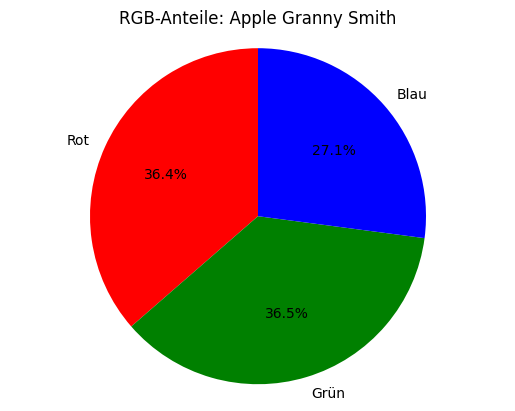

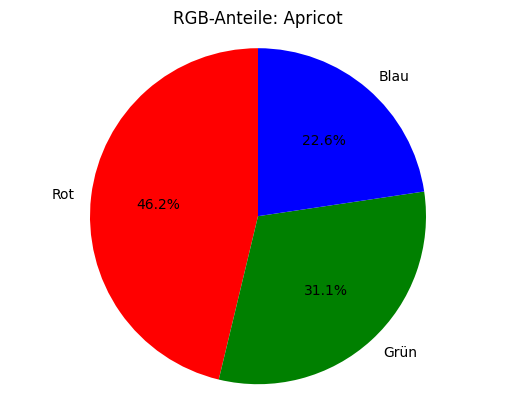

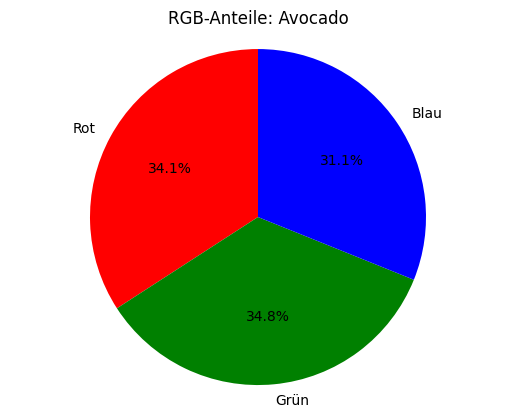

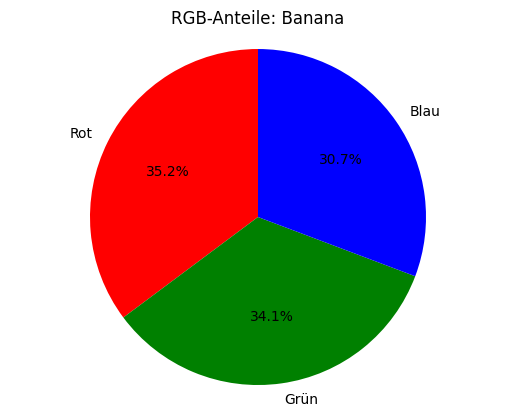

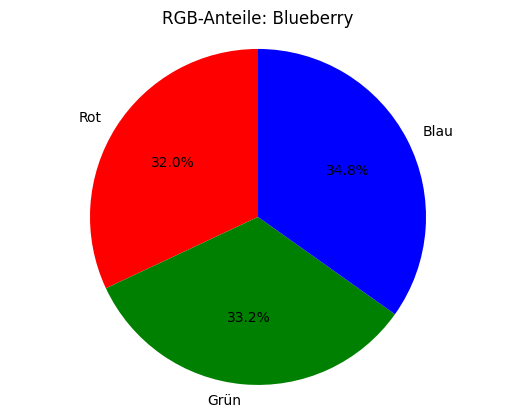

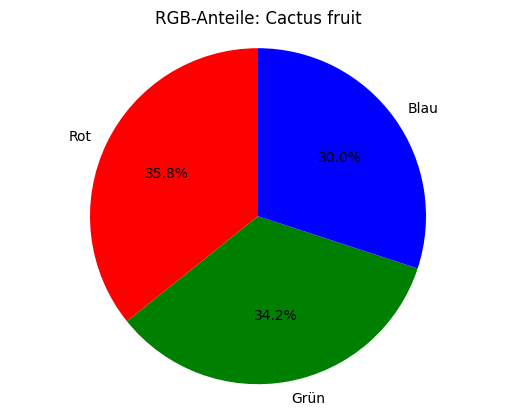

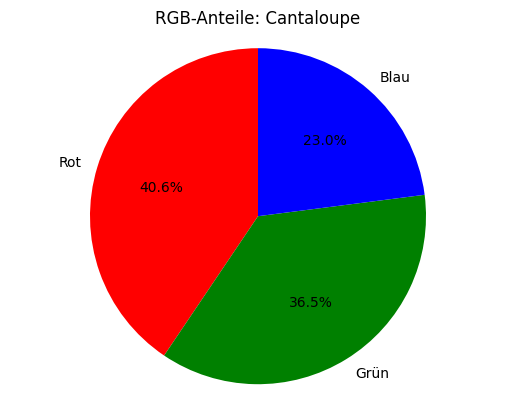

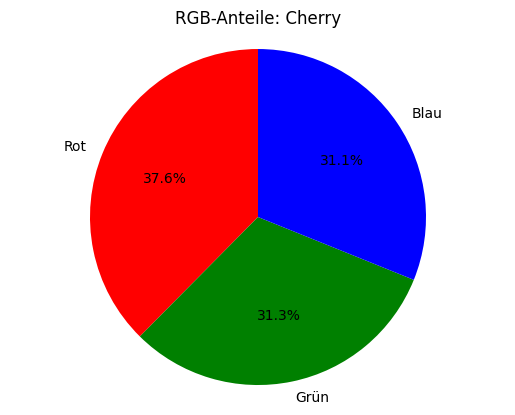

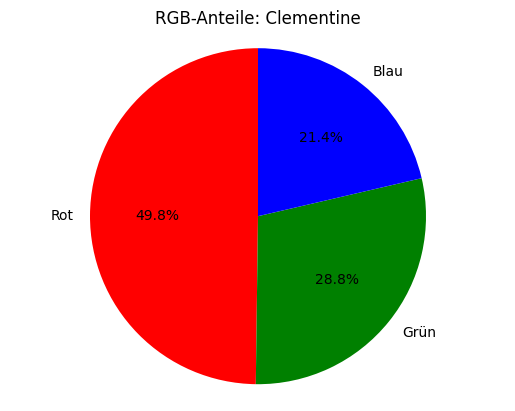

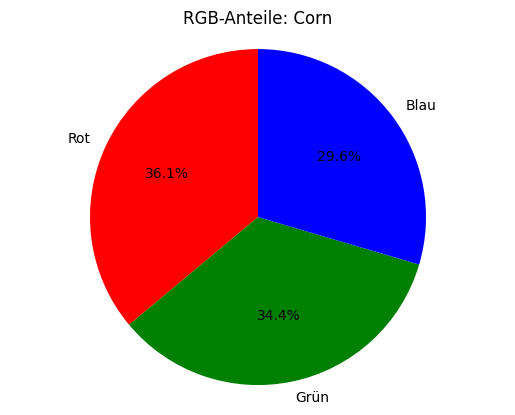

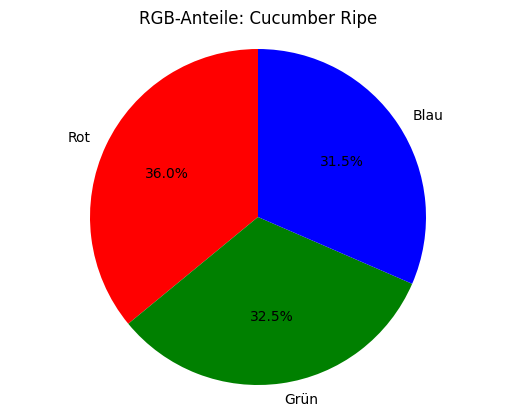

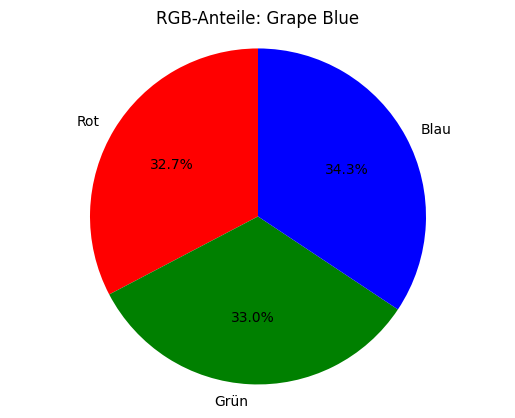

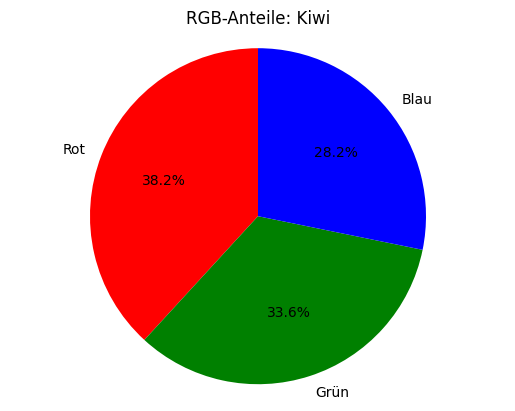

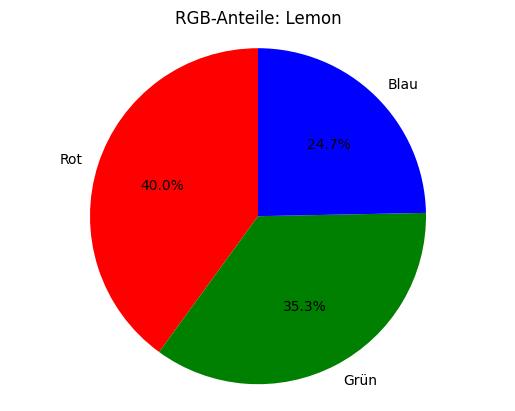

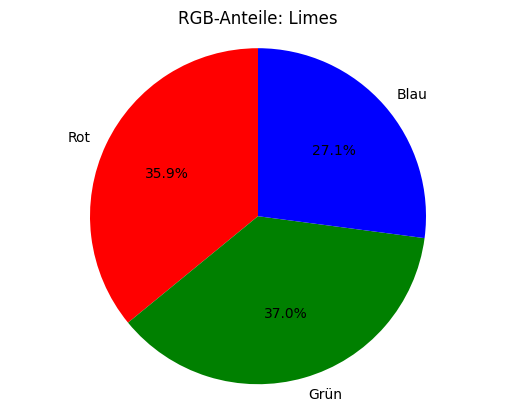

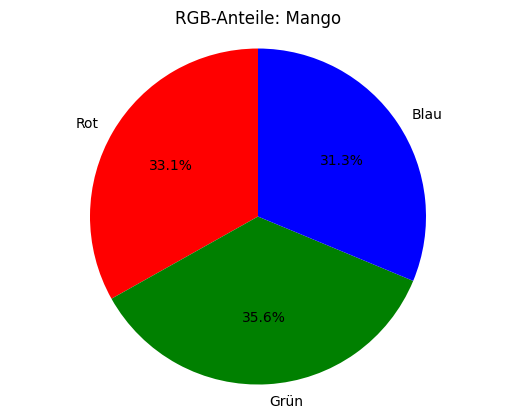

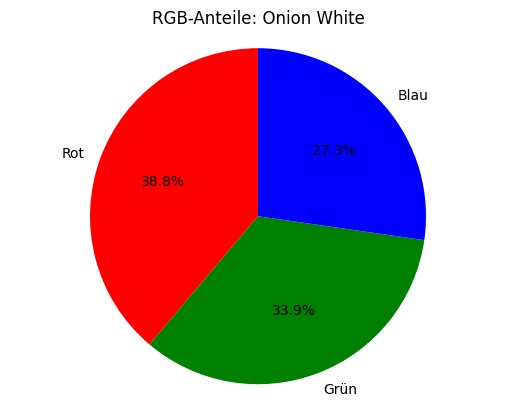

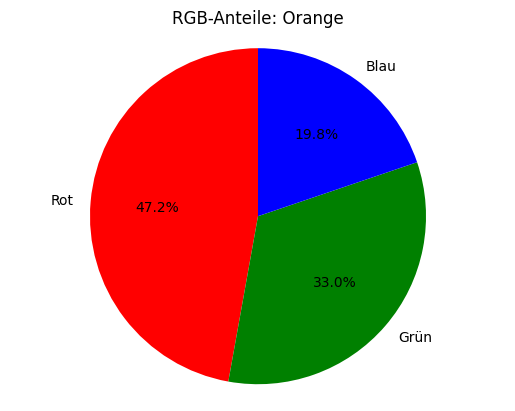

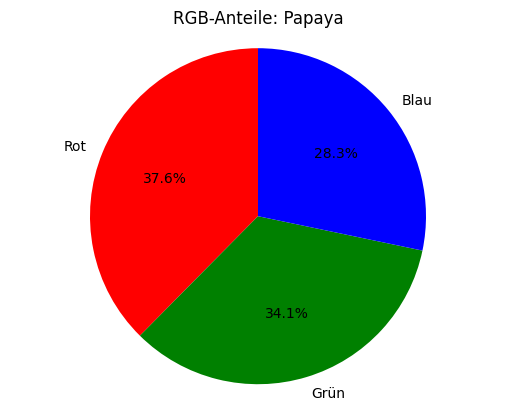

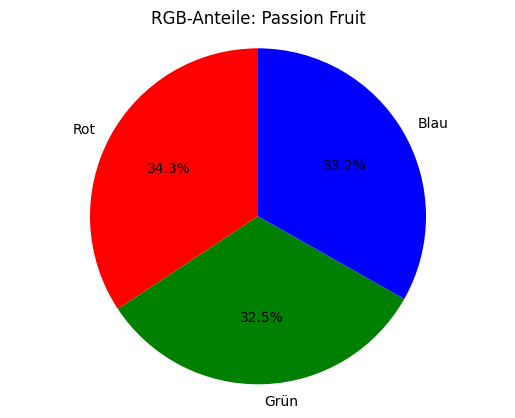

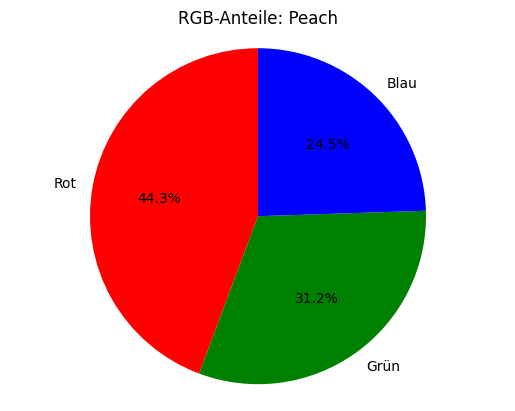

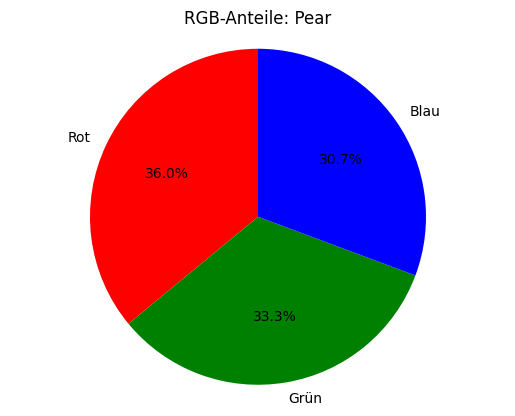

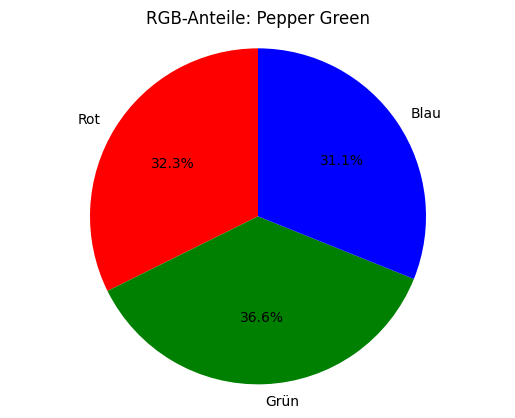

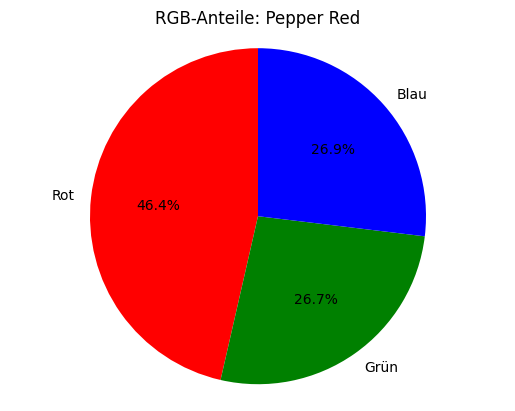

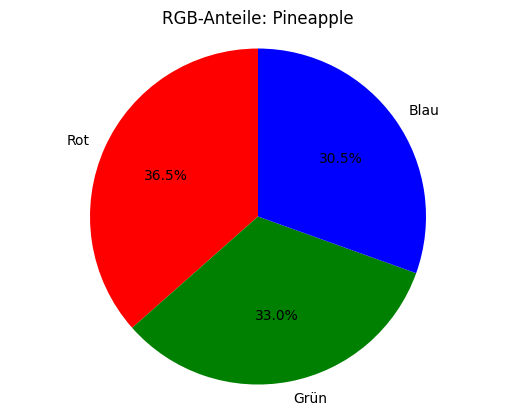

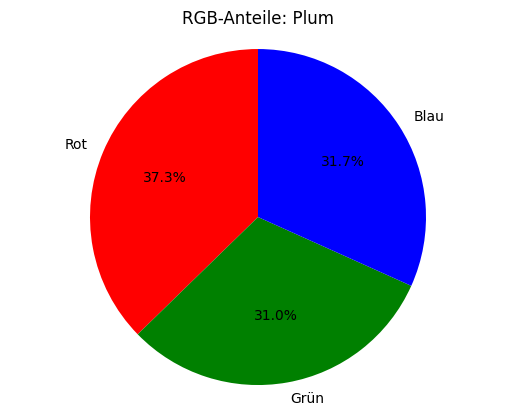

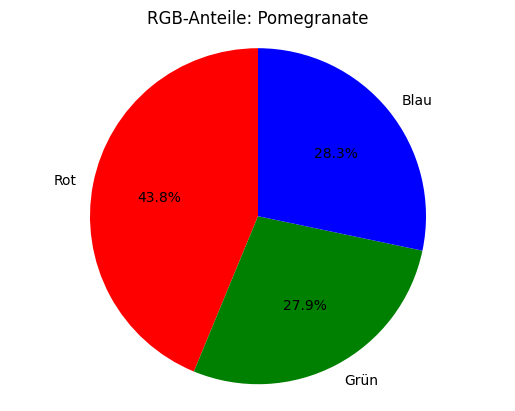

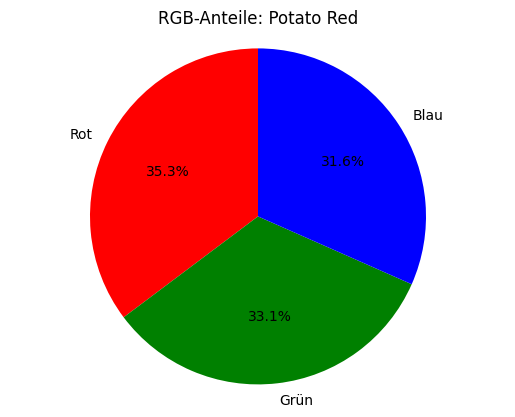

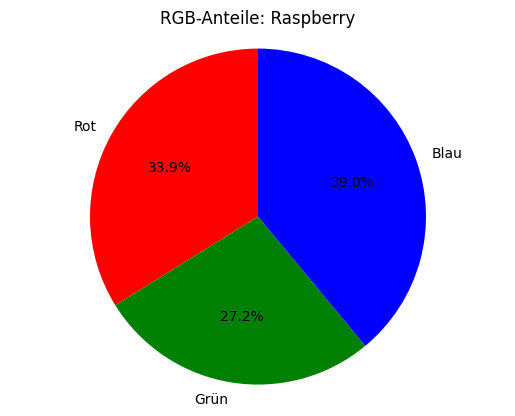

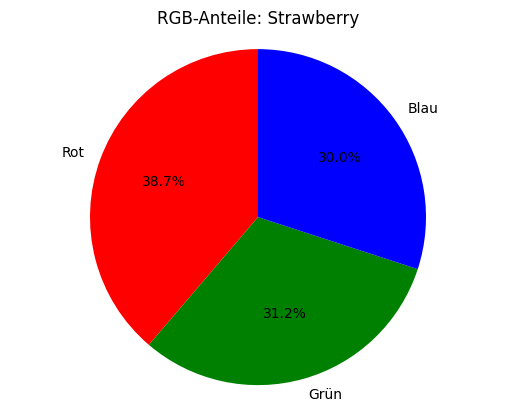

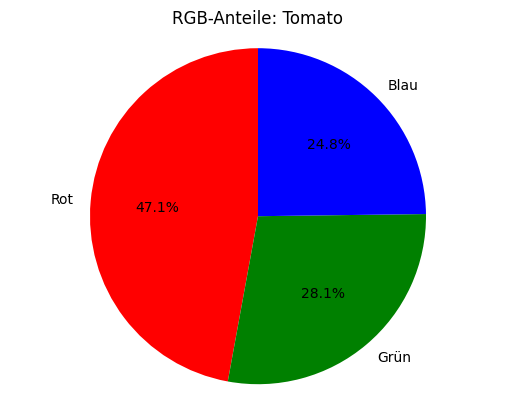

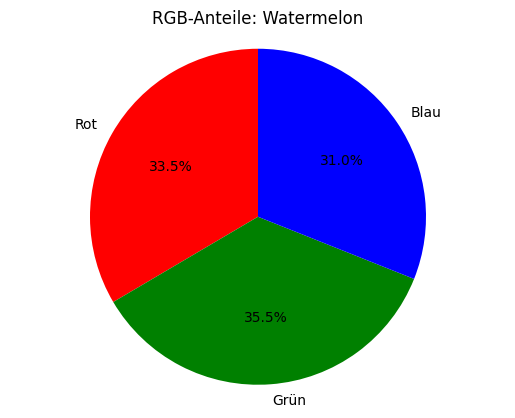

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

root_dir = train_dir  # dein Trainingsordner

for subfolder in os.listdir(root_dir):
    subfolder_path = os.path.join(root_dir, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    total_rgb = np.zeros(3, dtype=np.float64)  # [R, G, B]

    for file in os.listdir(subfolder_path):
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            img = Image.open(os.path.join(subfolder_path, file)).convert("RGB")
            img_np = np.array(img)

            # Summe aller Pixel pro Kanal
            total_rgb += img_np.reshape(-1, 3).sum(axis=0)

    if total_rgb.sum() == 0:
        continue

    # Prozentuale Anteile
    percentages = 100 * total_rgb / total_rgb.sum()

    # Pie Chart
    plt.figure()
    plt.pie(
        percentages,
        labels=["Rot", "Grün", "Blau"],
        colors=["red", "green", "blue"],
        autopct="%.1f%%",
        startangle=90
    )
    plt.title(f"RGB-Anteile: {subfolder}")
    plt.axis("equal")  # Kreis statt Oval
    plt.show()



In [8]:
train_dir = "Fruits/train/train"

In [9]:

# Annahme, dass alle Bilder jpgs und 100x100 von Höhe und Breite.
alle_100x100 = True
alle_jpg = True

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)       
        with Image.open(img_path) as img:
            # Extension vom Bild speichern.
            extension = os.path.splitext(img_path)[1].lower()
            if img.size != (100, 100):
                print(f"Bild nicht 100x100: {img_path}, Größe: {img.size}")
                alle_100x100 = False
            if extension != ".jpg":
                print("Bild nicht jpg, sondern "+extension)
                alle_jpg = False
            

if alle_100x100:
    print("Alle Bilder sind 100x100!")

if alle_jpg:
    print("Alle Bilder sind JPG.")


Alle Bilder sind 100x100!
Alle Bilder sind JPG.


In [10]:
def img_hash(path):
    "Hash eines Bildes aus der Datei"
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()  # MD5 Hash

hashes = {}
duplicates = []

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    for file in os.listdir(folder_path):       
        ## Verzerrt?
        img_path = os.path.join(folder_path, file)
        try:
            with Image.open(img_path) as img:
                # RGB Modus?
                if img.mode not in ["RGB", "L"]:
                    print("Ungewöhnlicher Modus:", img_path, "| Modus:", img.mode)
                # Verzerrtes Bild?
                if img.size[0] == 0 or img.size[1] == 0:
                    print("Verzerrtes Bild (0 Größe):", img_path)
        except Exception as e:
            print("Kaputtes / verzerrtes Bild:", img_path, "| Fehler:", e)
            continue

        ## Duplikate?
        path = os.path.join(folder_path, file)
        h = img_hash(path)
        if h in hashes:
            duplicates.append((path, hashes[h]))  # (aktuelles Bild, erstes gefundenes Duplikat)
        else:
            hashes[h] = path

print(f"Gefundene Duplikate: {len(duplicates)}")
for dup, original in duplicates:
    print(f"Duplikat: {dup} | Original: {original}")

Gefundene Duplikate: 0


In [11]:
folders = [
    f for f in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, f))
]

print("Anzahl Labels", len(folders))
print("\n")
# Iterierung durch die neue Variable folders.
anzahl_bilder = 0
for folder in sorted(folders):
    # "folder_path" ist jeweils der Pfad zum Ordner.
    folder_path = os.path.join(train_dir, folder)
    # Bilder werden in Variable "bild" gespeichert und mit der Funktion len wird die Anzahl Bilder herausgefunden.
    bild = len([
        image for image in os.listdir(folder_path)
    ])  
    # Die Bildanzahl wird der Variable "anzahl_bilder" aufaddiert, um später die Gesamtsumme aller Bilder auszugeben.
    anzahl_bilder += bild
    print(f"{folder}: {bild} Bilder")

print("\n")
print("Gesamtanzahl Bilder im Train-Set:", anzahl_bilder,"Bilder.")

Anzahl Labels 33


Apple Braeburn: 492 Bilder
Apple Granny Smith: 492 Bilder
Apricot: 492 Bilder
Avocado: 427 Bilder
Banana: 490 Bilder
Blueberry: 462 Bilder
Cactus fruit: 490 Bilder
Cantaloupe: 492 Bilder
Cherry: 492 Bilder
Clementine: 490 Bilder
Corn: 450 Bilder
Cucumber Ripe: 392 Bilder
Grape Blue: 984 Bilder
Kiwi: 466 Bilder
Lemon: 492 Bilder
Limes: 490 Bilder
Mango: 490 Bilder
Onion White: 438 Bilder
Orange: 479 Bilder
Papaya: 492 Bilder
Passion Fruit: 490 Bilder
Peach: 492 Bilder
Pear: 696 Bilder
Pepper Green: 444 Bilder
Pepper Red: 666 Bilder
Pineapple: 490 Bilder
Plum: 447 Bilder
Pomegranate: 492 Bilder
Potato Red: 450 Bilder
Raspberry: 490 Bilder
Strawberry: 492 Bilder
Tomato: 738 Bilder
Watermelon: 475 Bilder


Gesamtanzahl Bilder im Train-Set: 16854 Bilder.


In [13]:
# Alle Label-Ordner
folders = [f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))]

# Anzahl Bilder pro Klasse + Klassennamen speichern
count_to_labels = defaultdict(list)  # {Anzahl Bilder: [Klassenliste]}
bild_counts = []

for folder in sorted(folders):
    folder_path = os.path.join(train_dir, folder)
    count = len([f for f in os.listdir(folder_path)])
    bild_counts.append(count)
    count_to_labels[count].append(folder)

# Für Plotly: X = Bildanzahl, Y = Anzahl Klassen, Hovertext = Klassennamen
x_values = sorted(count_to_labels.keys())
y_values = [len(count_to_labels[x]) for x in x_values]
hover_texts = [", ".join(count_to_labels[x]) for x in x_values]

# Plotly Balkendiagramm
fig = go.Figure(data=[go.Bar(
    x=x_values,
    y=y_values,
    marker_color='skyblue',
    hovertext=hover_texts,  # Klassennamen beim Hover
    hoverinfo='x+text'
)])

# Layout anpassen
fig.update_layout(
    title="Verteilung der Bilder pro Klasse",
    xaxis_title="Anzahl Bilder pro Klasse",
    title_x=.5,
    yaxis_title="Anzahl Klassen",
    bargap=0.2,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color="black"),
    xaxis=dict(range=[0,1000], dtick=100, showline=True,linecolor='black',linewidth=.4),
    yaxis=dict(dtick=1, showline=True,linecolor='black',linewidth=.4)
)

fig.show()



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed